In [1]:
import sys, kardemumma
print(sys.executable)         # kernel Python
print(kardemumma.__file__)    # should point to your local repo under src/kardemumma

/home/thanadol/Documents/GitHub/kardemumma/.venv/bin/python
/home/thanadol/Documents/GitHub/kardemumma/src/kardemumma/__init__.py


In [2]:
# Load packages
from pathlib import Path
import os
import re
import sys
import importlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pyteomics import achrom
# Importantly, import kardemumma :)
import kardemumma as kdm

In [3]:

# Skyline data path
skyline_path = "data/DA4000/Kardemumma_v3_sept14.csv"

# Import skyline data (includes column "Isotope Label Type" from Precursor)
skyline_importer = kdm.ImportSkylineFile(skyline_path)
skyline_data = skyline_importer.import_skyline_file()

Importing Skyline file: data/DA4000/Kardemumma_v3_sept14.csv


/home/thanadol/Documents/GitHub/kardemumma/src/kardemumma/importer.py:218: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(self.file_path)


File data/DA4000/Kardemumma_v3_sept14.csv is valid.


In [4]:
# **SDRF**
sdrf_path = 'data/DA4000/20260917_DA4.5K.sdrf.tsv'

# Valdate sdrf fasta_file
# kdm.validate_sdrf(sdrf_path)
kdm.readout_ms_type(sdrf_path)
# Import SDRF file for this project

sdrf_data = kdm.ImportSDRFFile(sdrf_path)
sdrf_data_file = sdrf_data.import_sdrf_file()



Type(s) of MS experiment(s) in SDRF: NT=Parallel Reaction Monitoring;AC=MS:1002956, NT=Parallel Reaction Monitoring;AC=MS:1002957, NT=Parallel Reaction Monitoring;AC=MS:1002958, NT=Parallel Reaction Monitoring;AC=MS:1002959, NT=Parallel Reaction Monitoring;AC=MS:1002960, NT=Parallel Reaction Monitoring;AC=MS:1002961, NT=Parallel Reaction Monitoring;AC=MS:1002962, NT=Parallel Reaction Monitoring;AC=MS:1002963, NT=Parallel Reaction Monitoring;AC=MS:1002964, NT=Parallel Reaction Monitoring;AC=MS:1002965, NT=Parallel Reaction Monitoring;AC=MS:1002966, NT=Parallel Reaction Monitoring;AC=MS:1002967, NT=Parallel Reaction Monitoring;AC=MS:1002968, NT=Parallel Reaction Monitoring;AC=MS:1002969, NT=Parallel Reaction Monitoring;AC=MS:1002970, NT=Parallel Reaction Monitoring;AC=MS:1002971, NT=Parallel Reaction Monitoring;AC=MS:1002972, NT=Parallel Reaction Monitoring;AC=MS:1002973, NT=Parallel Reaction Monitoring;AC=MS:1002974, NT=Parallel Reaction Monitoring;AC=MS:1002975, NT=Parallel Reaction Mo

In [5]:
# # # Valdate sdrf 
# kdm.validate_sdrf(sdrf_path)

In [6]:
# Print out what Peptide Sequence iRT

kdm.get_irt_peptides(skyline_data)

Checking if the peptides are from Biognosys...
Not matched: ELDKYGVSDYHK, ELDKYGVSDYYK, NLINNAK, YGVSDYHK, SQTPAEDTVK, YGVSDYYK, SIELAEAK, TVEGVKDLQAQVVESAK, DLQAQVVESAK, ISEATDGLSDFLK
Number of peptides not matching Biognosys: 10

Number of iRT peptides: 10
iRT peptides: ['ELDKYGVSDYHK', 'YGVSDYHK', 'NLINNAK', 'TVEGVKDLQAQVVESAK', 'DLQAQVVESAK', 'ISEATDGLSDFLK', 'SQTPAEDTVK', 'SIELAEAK', 'ELDKYGVSDYYK', 'YGVSDYYK']



['ELDKYGVSDYHK',
 'YGVSDYHK',
 'NLINNAK',
 'TVEGVKDLQAQVVESAK',
 'DLQAQVVESAK',
 'ISEATDGLSDFLK',
 'SQTPAEDTVK',
 'SIELAEAK',
 'ELDKYGVSDYYK',
 'YGVSDYYK']

In [7]:
# Checking possible QC samples from Skyline results

qc_samples = skyline_importer.suggest_qc_samples(skyline_data)
# skyline_checker = CheckSkylineFile(skyline_path)

# Suggest qc samples

print(qc_samples)


Number of possible QC samples: 0
Possible QC samples: []
Consider removing these QC samples before further analysis.
[]


In [8]:
# # Plot retention time

# skyline_rt = skyline_data.copy()

# # Calculate mean retention time for each peptide
# mean_rt = skyline_data.groupby('Peptide Sequence')['Predicted Retention Time'].mean()

# # Sort peptides by mean retention time
# sorted_peptides = mean_rt.sort_values().index.tolist()

# # Calculate predicted RT using pyteomics.achrom's calculate_RT with Guo coefficients
# skyline_rt['RT'] = skyline_rt['Peptide Sequence'].apply(lambda seq: achrom.calculate_RT(seq, achrom.RCs_guo_ph7_0))

# skyline_rt.head()

In [9]:
# # Plot matching between predicted RT and experimental Predicted Retention Time

# plt.figure(figsize=(8, 6))
# plt.scatter(
#     skyline_rt['RT'],
#     skyline_rt['Predicted Retention Time'],
#     alpha=0.6,
#     s=20
# )
# plt.xlabel('Predicted RT (achrom Guo, pH 7.0)')
# plt.ylabel('Experimental RT (Skyline (Koina): Predicted Retention Time)')
# plt.title('Predicted vs. Experimental Retention Time for Peptides')
# plt.grid(True)
# plt.tight_layout()
# plt.show()


In [10]:
# Remove QC samples from skyline_data
skyline_data = kdm.remove_qc_samples(skyline_data, qc_samples)


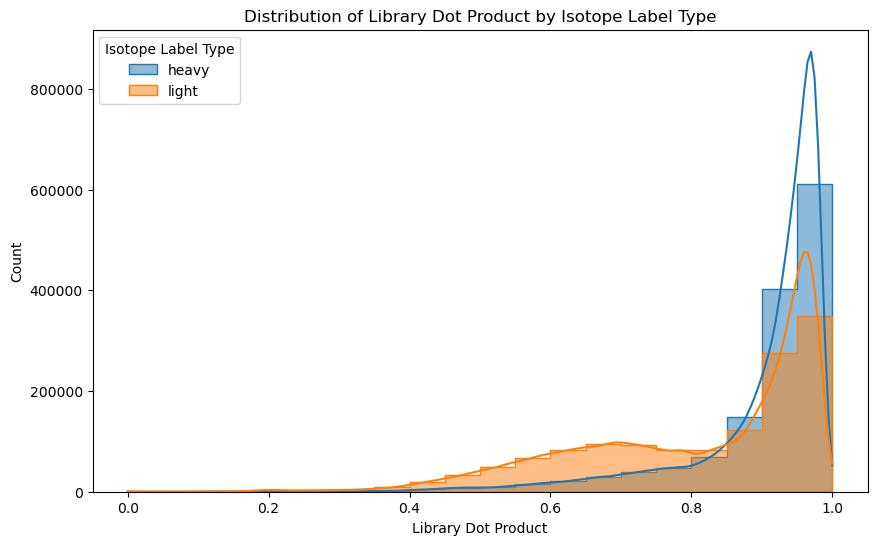

In [11]:
kdm.plot_library_dot_product_distribution(skyline_data)

In [12]:
skyline_clean = kdm.filter_library_dot_product(skyline_data, threshold=0.8)


Isotope Label Type
heavy    1195208
light     829706
Name: count, dtype: int64


In [13]:
# Summarise each peptide to count how many heavy or light signals are present in skyline_pivot
peptide_counts = kdm.summarise_peptide_counts(skyline_clean)


In [14]:
report_summary, peptide_list = kdm.report_peptide_protein_summary(peptide_counts)

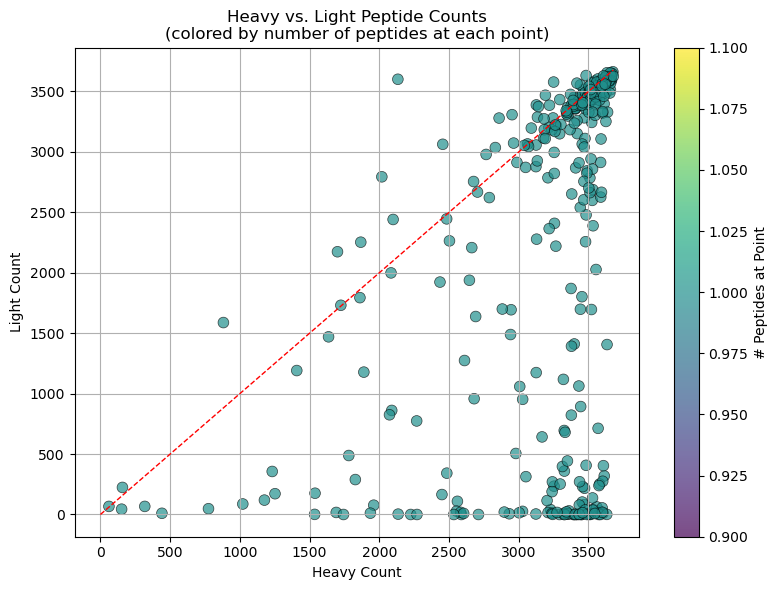

In [15]:
kdm.plot_heavy_light_scatter(peptide_counts)

In [16]:
filtered_peptide_counts = kdm.filter_peptide_counts(peptide_counts, light_cutoff=3000, heavy_cutoff=3000)

filtered_peptide_counts.head()


,Protein Name,Peptide,heavy_count,light_count
0,QR0140840_SERPINA6|P08185,ITQDAQLK,3124,3057
1,QR0140840_SERPINA6|P08185,MNTVIAALSR,3614,3578
2,QR0140840_SERPINA6|P08185,WSAGLTSSQVDLYIPK,3563,3529
3,QR0252445_ITIH3|Q06033,ALDLSLK,3502,3464
4,QR0260124_APOA4|P06727,DKVNSFFSTFK,3597,3545


In [17]:
selected_peptides_report, selected_peptides = kdm.report_peptide_protein_summary(filtered_peptide_counts)

In [18]:
# from kardemumma.importer import MergeFiles

skyline_merge_obj = kdm.MergeFiles(skyline_data, sdrf_data_file, selected_peptides)
skyline_merge = skyline_merge_obj.merge_files()

Sample names in Skyline but not in SDRF (291).
----------------------------------------
Sample names in SDRF but not in Skyline (223).


In [19]:
skyline_merge_obj.mistmatched_samples().to_csv("mismatched_samples.csv", index=False)

Mismatch summary (Files present in ONLY Skyline or ONLY SDRF):
                                     Files  Skyline  SDRF suggested date
0          PRM_20260621_DA4K_B5_P17_G8.raw        1     0       20260621
1          PRM_20260621_DA4K_B5_P17_G7.raw        1     0       20260621
2          PRM_20260621_DA4K_B5_P17_G6.raw        1     0       20260621
3          PRM_20260621_DA4K_B5_P17_G5.raw        1     0       20260621
4          PRM_20260621_DA4K_B5_P17_G4.raw        1     0       20260621
..                                     ...      ...   ...            ...
509  DIA_20260508_DA_4K_B3_Plate_10_C3.raw        0     1       20260508
510  DIA_20260508_DA_4K_B3_Plate_10_C4.raw        0     1       20260508
511  DIA_20260508_DA_4K_B3_Plate_10_C5.raw        0     1       20260508
512        PRM_20260811_DA4K_B9_P34_C6.raw        0     1       20260811
513        PRM_20260811_DA4K_B9_P34_H8.raw        0     1       20260811

[514 rows x 4 columns]


In [20]:
skyline_pool = skyline_merge_obj.select_pool_data(label_col='characteristics[Sample]', pool_label='PlasmaPool')
# Need to check printing????

Summary of samples per plate:
Plate Plate_1: 5 unique comment[data file] names
Plate Plate_11: 5 unique comment[data file] names
Plate Plate_12: 5 unique comment[data file] names
Plate Plate_13: 4 unique comment[data file] names
Plate Plate_14: 5 unique comment[data file] names
Plate Plate_15: 5 unique comment[data file] names
Plate Plate_16: 4 unique comment[data file] names
Plate Plate_18: 5 unique comment[data file] names
Plate Plate_19: 5 unique comment[data file] names
Plate Plate_2: 5 unique comment[data file] names
Plate Plate_20: 4 unique comment[data file] names
Plate Plate_21: 5 unique comment[data file] names
Plate Plate_22: 5 unique comment[data file] names
Plate Plate_23: 5 unique comment[data file] names
Plate Plate_24: 4 unique comment[data file] names
Plate Plate_25: 5 unique comment[data file] names
Plate Plate_26: 5 unique comment[data file] names
Plate Plate_27: 5 unique comment[data file] names
Plate Plate_28: 5 unique comment[data file] names
Plate Plate_29: 5 uniq

In [21]:
skyline_pool.head()

,Precursor,Replicate,File Name,Peptide Retention Time,Precursor Charge,Peptide Sequence,Normalized Area,RatioLightToHeavy,Ratio Dot Product,Library Dot Product,...,characteristics[developmental stage],characteristics[sex],characteristics[ancestry category],characteristics[cell type],characteristics[cell line],characteristics[disease],characteristics[disease category],characteristics[individual],characteristics[biological replicate],factor value[disease]
0,741.3798++ (heavy),04_DA4K_B9_P31_A1,PRM_20260804_DA4K_B9_P31_A1.raw,15.34,2,AAVYHHFISDGVR,4.5803E+4,0.9639,NaN,0.9007,...,not available,not available,not available,not available,not available,24_random,NaN,not available,1.0,24_random
1,736.3757++,04_DA4K_B9_P31_A1,PRM_20260804_DA4K_B9_P31_A1.raw,15.34,2,AAVYHHFISDGVR,4.5803E+4,0.9639,0.8907,0.8859,...,not available,not available,not available,not available,not available,24_random,NaN,not available,1.0,24_random
2,539.9587+++ (heavy),04_DA4K_B9_P31_A1,PRM_20260804_DA4K_B9_P31_A1.raw,13.93,3,AAVYHHFISDGVRK,1.9579E+5,0.8795,NaN,0.9136,...,not available,not available,not available,not available,not available,24_random,NaN,not available,1.0,24_random
3,533.9512+++,04_DA4K_B9_P31_A1,PRM_20260804_DA4K_B9_P31_A1.raw,13.93,3,AAVYHHFISDGVRK,1.9579E+5,0.8795,0.9794,0.9138,...,not available,not available,not available,not available,not available,24_random,NaN,not available,1.0,24_random
4,664.8145++ (heavy),04_DA4K_B9_P31_A1,PRM_20260804_DA4K_B9_P31_A1.raw,16.87,2,ACIPTGPYPCGK,5.1914E+4,0.7520,NaN,0.9224,...,not available,not available,not available,not available,not available,24_random,NaN,not available,1.0,24_random


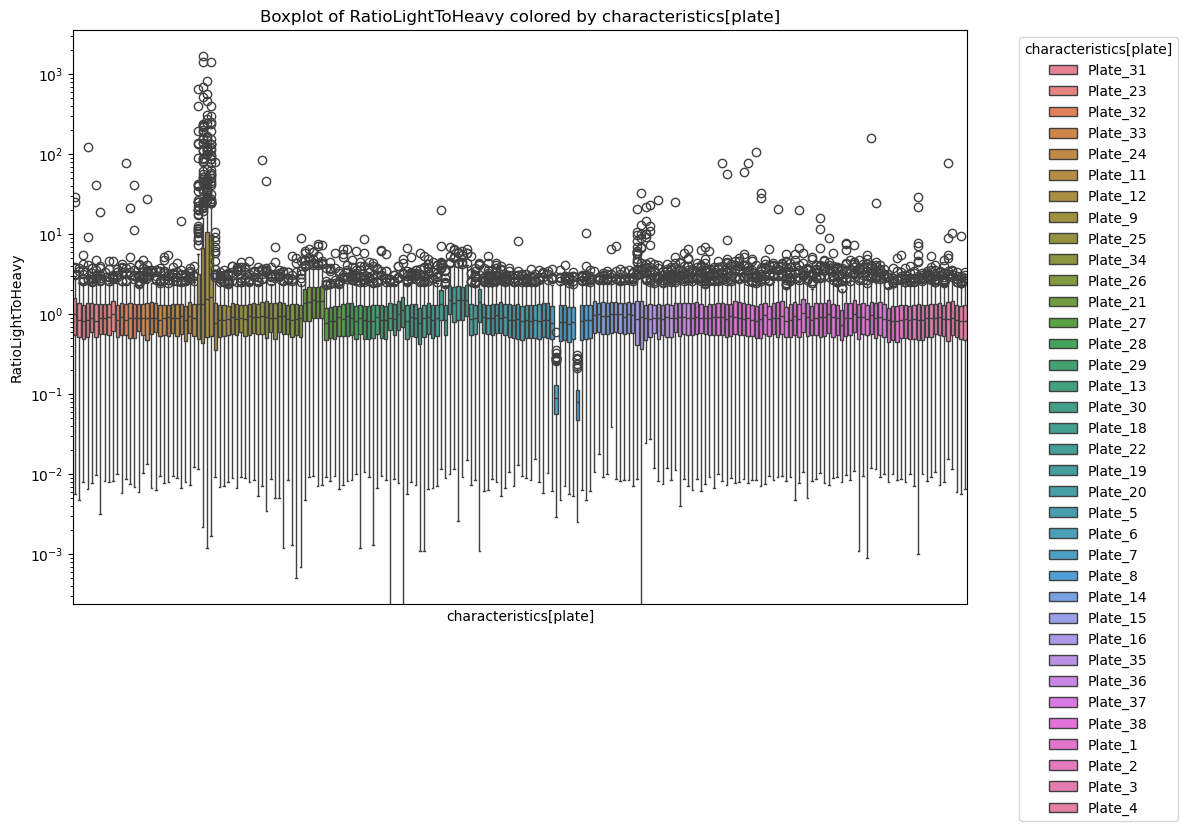

In [22]:
# Plot log_ratio of each sample in boxplot, colored by plate, but x-axis is Replicate, sorted by plate (though x labels are hidden).
kdm.plot_pool_boxplot(skyline_pool)


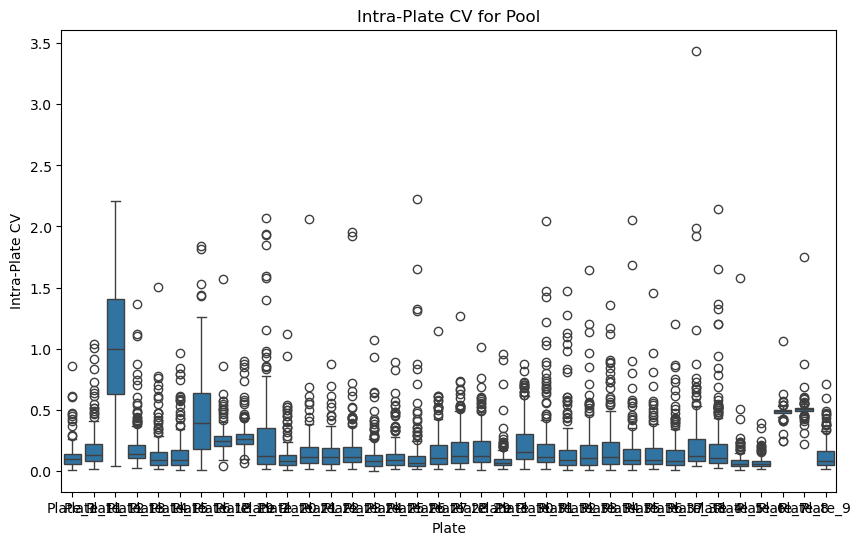

In [23]:
# Calculate intra-plate CV

peptide_plate_stats = kdm.calculate_intra_plate_cv(skyline_pool, col_name='characteristics[plate]')
kdm.plot_intra_plate_cv_stats(peptide_plate_stats, col_name='characteristics[plate]')

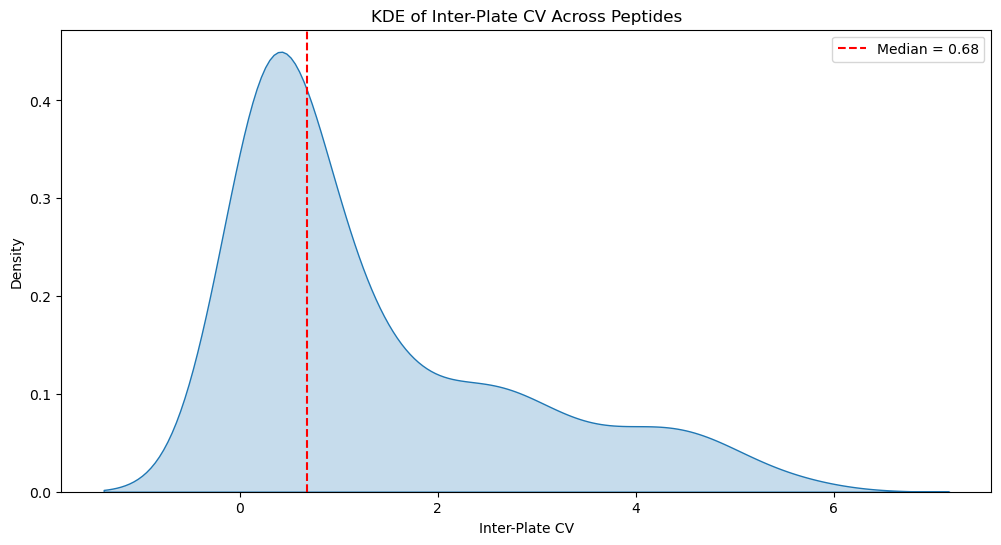

In [24]:
interplate_cv = kdm.calculate_inter_plate_cv(peptide_plate_stats)
kdm.plot_inter_plate_cv_kde(interplate_cv)

In [25]:
interplate_cv.head()

,Peptide Sequence,grand_mean,between_plate_sd,inter_plate_cv
0,EIEEVLTPEMLMR,1.341463,0.176184,0.131337
1,GYTLADNGK,0.529940,0.077017,0.145331
2,VQPYLDDFQK,2.819198,0.444136,0.157540
3,SWFEPLVEDMQR,0.838772,0.136797,0.163093
4,ITQDAQLK,0.897408,0.160354,0.178686


In [26]:
# Print interplate_cv froom low to high
print('This is the interplate_cv from low to high:')
print(interplate_cv[interplate_cv['inter_plate_cv'] < 0.1])

This is the interplate_cv from low to high:
Empty DataFrame
Columns: [Peptide Sequence, grand_mean, between_plate_sd, inter_plate_cv]
Index: []


Total peptides: 185
  CV < 10%: 0 peptides
  CV < 20%: 18 peptides


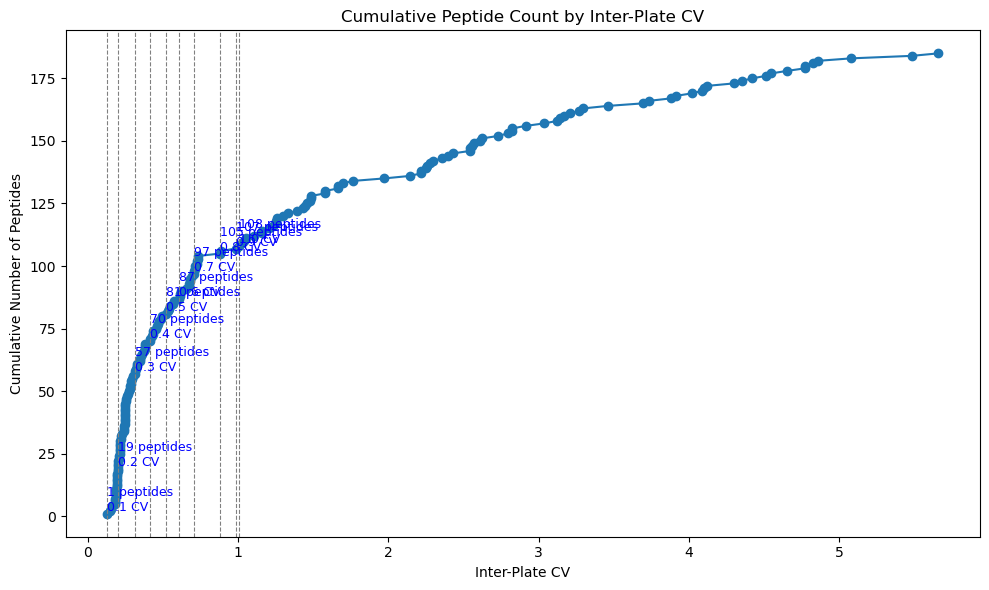

In [27]:
kdm.plot_cumulative_peptide_count_by_cv(interplate_cv)

In [28]:
selected_peptides = kdm.get_lowest_cv_peptides(interplate_cv, 17)
selected_peptides

array(['EIEEVLTPEMLMR', 'GYTLADNGK', 'VQPYLDDFQK', 'SWFEPLVEDMQR'],
      dtype=object)

In [29]:
# Batch/Plate adjustment, correcting for each peptide within each plate (batch) 
# using only peptides in the top 10% lowest inter-plate CV for normalization

pool_selected_df = skyline_pool[skyline_pool['Peptide Sequence'].isin(selected_peptides)]

# Remove bad plasmapool 

# bad_pools = [
#        'PRM_20260422_DA_4K_B2_Plate_7_C1.raw',
#        'PRM_20260422_DA_4K_B2_Plate_8_B8.raw']


# # Remove bad peptides 
# bad_peptides = ['ESDTSYVSLK', 'VTLNGVPAQPLGPR', 'FSIEGSYQLEK', 'GLLSGWAR']

# # Filter bad_pools from pool_selected_df
# pool_selected_df = pool_selected_df[~pool_selected_df['File Name'].isin(bad_pools)]

# # Filter bad_peptides from pool_selected_df
# pool_selected_df = pool_selected_df[~pool_selected_df['Peptide Sequence'].isin(bad_peptides)]

# Filter pool_data to include only those peptides for normalization calculation
pool_selected_df

,Precursor,Replicate,File Name,Peptide Retention Time,Precursor Charge,Peptide Sequence,Normalized Area,RatioLightToHeavy,Ratio Dot Product,Library Dot Product,...,characteristics[developmental stage],characteristics[sex],characteristics[ancestry category],characteristics[cell type],characteristics[cell line],characteristics[disease],characteristics[disease category],characteristics[individual],characteristics[biological replicate],factor value[disease]
46,800.4034++ (heavy),04_DA4K_B9_P31_A1,PRM_20260804_DA4K_B9_P31_A1.raw,26.83,2,EIEEVLTPEMLMR,2.2338E+3,0.5014,NaN,0.6274,...,not available,not available,not available,not available,not available,24_random,NaN,not available,1.0,24_random
47,795.3993++,04_DA4K_B9_P31_A1,PRM_20260804_DA4K_B9_P31_A1.raw,26.83,2,EIEEVLTPEMLMR,2.2338E+3,0.5014,0.6880,0.6035,...,not available,not available,not available,not available,not available,24_random,NaN,not available,1.0,24_random
104,473.7396++ (heavy),04_DA4K_B9_P31_A1,PRM_20260804_DA4K_B9_P31_A1.raw,13.49,2,GYTLADNGK,4.8834E+4,0.4985,NaN,0.9533,...,not available,not available,not available,not available,not available,24_random,NaN,not available,1.0,24_random
105,469.7325++,04_DA4K_B9_P31_A1,PRM_20260804_DA4K_B9_P31_A1.raw,13.49,2,GYTLADNGK,4.8834E+4,0.4985,0.9389,0.9504,...,not available,not available,not available,not available,not available,24_random,NaN,not available,1.0,24_random
260,773.8653++ (heavy),04_DA4K_B9_P31_A1,PRM_20260804_DA4K_B9_P31_A1.raw,28.31,2,SWFEPLVEDMQR,1.4623E+4,1.4778,NaN,0.6293,...,not available,not available,not available,not available,not available,24_random,NaN,not available,1.0,24_random
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77435,469.7325++,DA_4K_B1_Plate4_G4,PRM_20260410_DA_4K_B1_Plate4_G4.raw,13.16,2,GYTLADNGK,4.6493E+5,0.4429,0.9380,0.9409,...,not available,not available,not available,not available,not available,NaN,Healthy,not available,1.0,NaN
77590,773.8653++ (heavy),DA_4K_B1_Plate4_G4,PRM_20260410_DA_4K_B1_Plate4_G4.raw,26.36,2,SWFEPLVEDMQR,5.0969E+6,0.8322,NaN,0.9676,...,not available,not available,not available,not available,not available,NaN,Healthy,not available,1.0,NaN
77591,768.8612++,DA_4K_B1_Plate4_G4,PRM_20260410_DA_4K_B1_Plate4_G4.raw,26.36,2,SWFEPLVEDMQR,5.0969E+6,0.8322,0.9827,0.9664,...,not available,not available,not available,not available,not available,NaN,Healthy,not available,1.0,NaN
77652,630.8212++ (heavy),DA_4K_B1_Plate4_G4,PRM_20260410_DA_4K_B1_Plate4_G4.raw,18.80,2,VQPYLDDFQK,5.0273E+8,3.0671,NaN,0.9836,...,not available,not available,not available,not available,not available,NaN,Healthy,not available,1.0,NaN


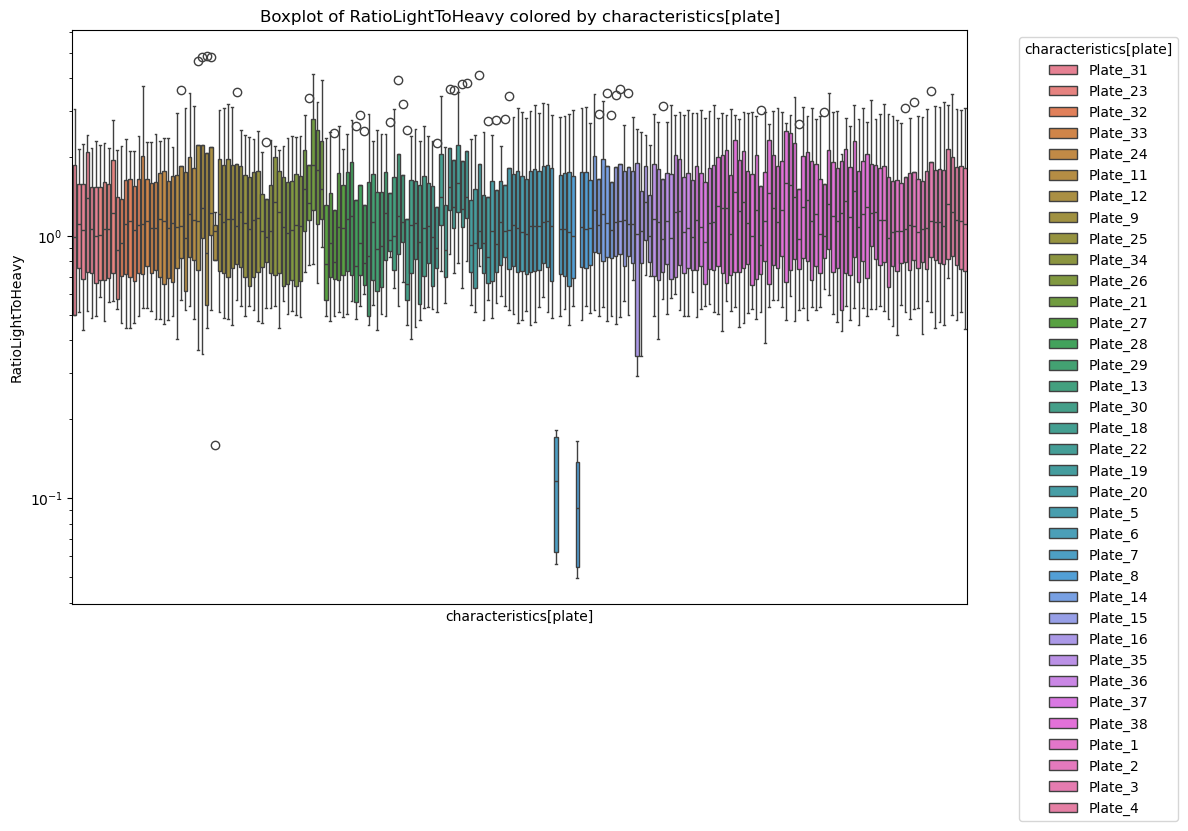

In [30]:
kdm.plot_pool_boxplot(pool_selected_df)

In [31]:
plate_factor_table, conversion_factors, model = kdm.get_plate_conversion_factors(pool_selected_df, col_plate='characteristics[plate]', log_transform=True  )

Conversion factors: {'Plate_1': 1.5711972491767028, 'Plate_11': 0.6198423829858866, 'Plate_12': 0.3491643702170774, 'Plate_13': 1.32955142016173, 'Plate_14': 0.6788370721913803, 'Plate_15': 0.4789725008753403, 'Plate_16': 0.5524076117464092, 'Plate_18': -10.888436076347652, 'Plate_19': -1.0877102561364136, 'Plate_2': 1.0163325065000117, 'Plate_20': 21.25422962123057, 'Plate_21': 0.153528503838309, 'Plate_22': 0.15652954378750186, 'Plate_23': -1.0513930470678572, 'Plate_24': 1.847928236536163, 'Plate_25': 0.5258301204713912, 'Plate_26': -10.70933561341031, 'Plate_27': -0.24784139978467626, 'Plate_28': -0.35132586422569867, 'Plate_29': 4.789163110504827, 'Plate_3': 0.5199965743017837, 'Plate_30': -0.4035844125616137, 'Plate_31': 1.3802893371995464, 'Plate_32': -0.8962844157462843, 'Plate_33': 0.9165913608330996, 'Plate_34': -2.7736299914476517, 'Plate_35': 8.446772508378036, 'Plate_36': 3.7659074367190724, 'Plate_37': 6.4695302511630075, 'Plate_38': 0.9395929232667014, 'Plate_4': 0.35667

In [32]:
plate_factor_table

,characteristics[plate],plate_median,correction_factor
0,Plate_1,0.032778,1.571197
1,Plate_11,0.083087,0.619842
2,Plate_12,0.147497,0.349164
3,Plate_13,0.038735,1.329551
4,Plate_14,0.075866,0.678837
5,Plate_15,0.107523,0.478973
6,Plate_16,0.093229,0.552408
7,Plate_18,-0.004730,-10.888436
8,Plate_19,-0.047348,-1.087710
9,Plate_2,0.050673,1.016333


In [33]:
conversion_factors

{'Plate_1': 1.5711972491767028,
 'Plate_11': 0.6198423829858866,
 'Plate_12': 0.3491643702170774,
 'Plate_13': 1.32955142016173,
 'Plate_14': 0.6788370721913803,
 'Plate_15': 0.4789725008753403,
 'Plate_16': 0.5524076117464092,
 'Plate_18': -10.888436076347652,
 'Plate_19': -1.0877102561364136,
 'Plate_2': 1.0163325065000117,
 'Plate_20': 21.25422962123057,
 'Plate_21': 0.153528503838309,
 'Plate_22': 0.15652954378750186,
 'Plate_23': -1.0513930470678572,
 'Plate_24': 1.847928236536163,
 'Plate_25': 0.5258301204713912,
 'Plate_26': -10.70933561341031,
 'Plate_27': -0.24784139978467626,
 'Plate_28': -0.35132586422569867,
 'Plate_29': 4.789163110504827,
 'Plate_3': 0.5199965743017837,
 'Plate_30': -0.4035844125616137,
 'Plate_31': 1.3802893371995464,
 'Plate_32': -0.8962844157462843,
 'Plate_33': 0.9165913608330996,
 'Plate_34': -2.7736299914476517,
 'Plate_35': 8.446772508378036,
 'Plate_36': 3.7659074367190724,
 'Plate_37': 6.4695302511630075,
 'Plate_38': 0.9395929232667014,
 'Plate_4

/home/thanadol/Documents/GitHub/kardemumma/src/kardemumma/prm.py:666: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_df["Peptide Sequence"] = pd.Categorical(


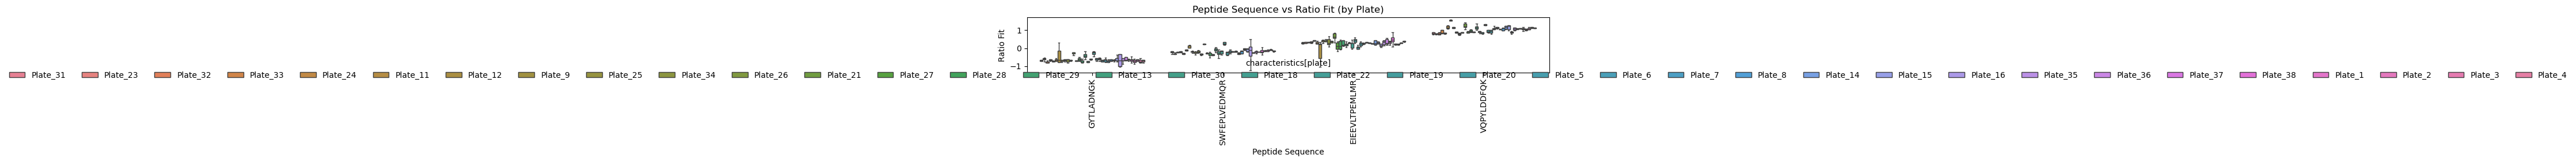

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [34]:
kdm.plot_plate_conversion_factors(pool_selected_df, col_plate='characteristics[plate]', log_transform=True  )

In [35]:
# Use the adjust_ratio_by_plate function above to add RatioLightToHeavy_adj to skyline_merge
# First, construct a Plate column of the correct type for the function
skyline_merge_adj = skyline_merge.copy()
# Remove samples from Replicate column that are in qc_samples
skyline_merge_adj = skyline_merge_adj[~skyline_merge_adj['Replicate'].isin(qc_samples)]

# Remove sampels from Plate_1 from characteristics[plate]
skyline_merge_adj = skyline_merge_adj[skyline_merge_adj['characteristics[plate]'] != 'Plate_1']


In [36]:
# Adjust ratio by conversion factor 
skyline_merge_adj = kdm.adjust_ratio_by_plate(skyline_merge_adj, conversion_factors)

skyline_merge_adj.head()

,Precursor,Replicate,File Name,Peptide Retention Time,Precursor Charge,Peptide Sequence,Normalized Area,RatioLightToHeavy,Ratio Dot Product,Library Dot Product,...,characteristics[developmental stage],characteristics[sex],characteristics[ancestry category],characteristics[cell type],characteristics[cell line],characteristics[disease],characteristics[disease category],characteristics[individual],characteristics[biological replicate],factor value[disease]
0,488.2589++,B2_Plate_5_A1,PRM_20260422_DA_4K_B2_Plate_5_A1.raw,13.75,2,ISASAEELR,3.2573E+7,1.625086,0.9623,0.9840,...,not available,not available,not available,not available,not available,Multiple sclerosis,Neurologic,not available,1.0,Multiple sclerosis
1,488.2589++,B2_Plate_5_A2,PRM_20260422_DA_4K_B2_Plate_5_A2.raw,13.72,2,ISASAEELR,2.0071E+7,0.962536,0.9614,0.9713,...,not available,not available,not available,not available,not available,Coronary artery disease,Cardiovascular,not available,1.0,Coronary artery disease
2,488.2589++,B2_Plate_5_A3,PRM_20260422_DA_4K_B2_Plate_5_A3.raw,13.69,2,ISASAEELR,3.9832E+7,2.524674,0.9533,0.9766,...,not available,not available,not available,not available,not available,Coronary artery disease,Cardiovascular,not available,1.0,Coronary artery disease
3,488.2589++,B2_Plate_5_A4,PRM_20260422_DA_4K_B2_Plate_5_A4.raw,13.83,2,ISASAEELR,1.8734E+7,0.967884,0.9866,0.9835,...,not available,not available,not available,not available,not available,Coronary artery disease,Cardiovascular,not available,1.0,Coronary artery disease
4,488.2589++,B2_Plate_5_A5,PRM_20260422_DA_4K_B2_Plate_5_A5.raw,13.58,2,ISASAEELR,2.7496E+7,1.616049,0.9493,0.9537,...,not available,not available,not available,not available,not available,Nonalcoholic steatohepatitis,Metabolic,not available,1.0,Nonalcoholic steatohepatitis


In [37]:
# From skyline_merge_adj, filter to pool samples
pool_data_adj = skyline_merge_adj[skyline_merge_adj['characteristics[Sample]'] != 'PlasmaPool'].copy()

# Reorder by characteristics[Plate]
pool_data_adj = pool_data_adj.sort_values(by='characteristics[plate]')

# Remove outliner by Ratio Dot Product less than 10**1
pool_data_adj = pool_data_adj[pool_data_adj['RatioLightToHeavy'] <= 10**10]

pool_data_adj.head()


,Precursor,Replicate,File Name,Peptide Retention Time,Precursor Charge,Peptide Sequence,Normalized Area,RatioLightToHeavy,Ratio Dot Product,Library Dot Product,...,characteristics[developmental stage],characteristics[sex],characteristics[ancestry category],characteristics[cell type],characteristics[cell line],characteristics[disease],characteristics[disease category],characteristics[individual],characteristics[biological replicate],factor value[disease]
427578,637.8224++,08_DA_4K_B3_Plate_11_C1,PRM_20260508_DA_4K_B3_Plate_11_C1.raw,10.78,2,HYEGSTVPEKK,6.6333E+6,2.726661,0.9407,0.9308,...,not available,not available,not available,not available,not available,Healthy,Healthy,not available,1.0,Healthy
169974,632.8302++,08_DA_4K_B3_Plate_11_H11,PRM_20260508_DA_4K_B3_Plate_11_H11.raw,18.36,2,SGLSTGWTQLSK,1.0877E+7,1.972437,0.9259,0.9045,...,not available,not available,not available,not available,not available,case,NaN,not available,1.0,case
169973,632.8302++,08_DA_4K_B3_Plate_11_H10,PRM_20260508_DA_4K_B3_Plate_11_H10.raw,19.20,2,SGLSTGWTQLSK,1.0614E+8,5.215681,0.9285,0.9071,...,not available,not available,not available,not available,not available,Pancreatic ductal adenocarcinoma,Cancer,not available,1.0,Pancreatic ductal adenocarcinoma
169971,632.8302++,08_DA_4K_B3_Plate_11_H8,PRM_20260508_DA_4K_B3_Plate_11_H8.raw,18.69,2,SGLSTGWTQLSK,7.6165E+7,4.785087,0.8868,0.9009,...,not available,not available,not available,not available,not available,Systemic sclerosis,Autoimmune,not available,1.0,Systemic sclerosis
169970,632.8302++,08_DA_4K_B3_Plate_11_H7,PRM_20260508_DA_4K_B3_Plate_11_H7.raw,19.03,2,SGLSTGWTQLSK,8.2166E+7,4.157025,0.9285,0.9056,...,not available,not available,not available,not available,not available,Rheumatoid arthritis,Autoimmune,not available,1.0,Rheumatoid arthritis


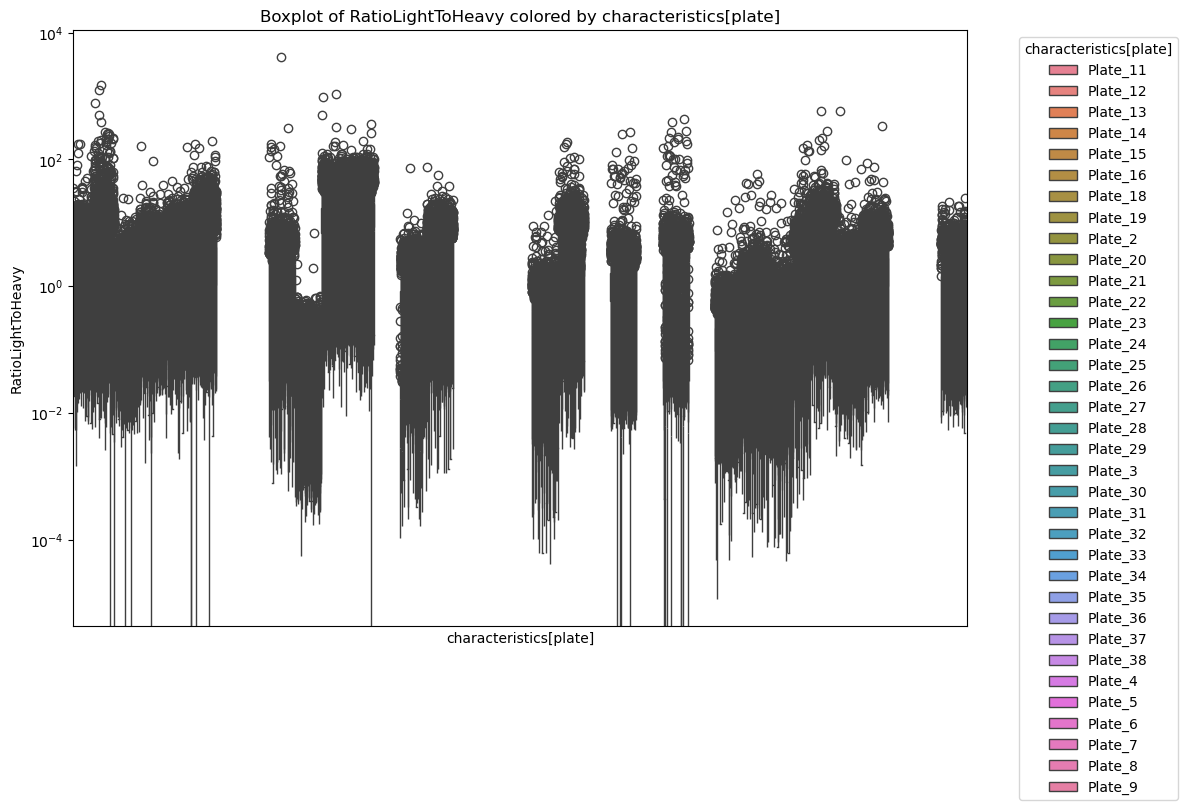

In [38]:
kdm.plot_pool_boxplot(pool_data_adj)

/home/thanadol/Documents/GitHub/kardemumma/.venv/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/thanadol/Documents/GitHub/kardemumma/.venv/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/thanadol/Documents/GitHub/kardemumma/src/kardemumma/prm.py:666: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_df["Peptide Sequence"] = pd.Categorical(


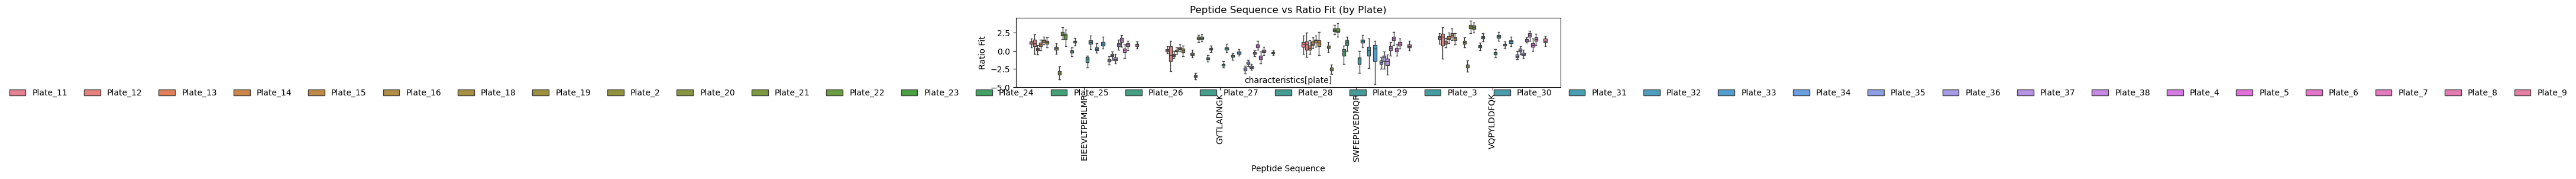

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [39]:
pool_selected_adj = pool_data_adj[pool_data_adj['Peptide Sequence'].isin(selected_peptides)]

kdm.plot_plate_conversion_factors(pool_selected_adj, col_plate='characteristics[plate]', log_transform=True  )

# SDRF metadata

Overview of metadata

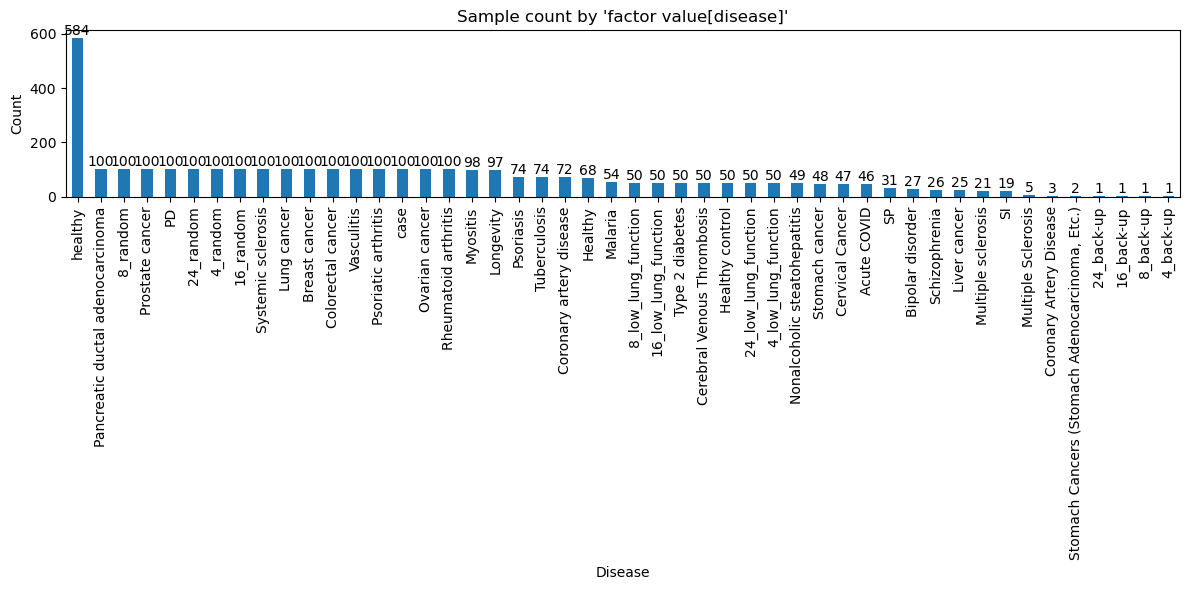

In [40]:
import matplotlib.pyplot as plt

# Make a barplot of 'factor value[disease]' column
plt.figure(figsize=(12,6))
value_counts = sdrf_data_file['factor value[disease]'].value_counts()
ax = value_counts.plot(kind='bar')
plt.xlabel('Disease')
plt.ylabel('Count')
plt.title("Sample count by 'factor value[disease]'")
plt.tight_layout()

# Add number on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom', fontsize=10)

plt.show()

# Calculate absolute quantification

In [41]:
# kdm.validate_sdrf(sdrf_path)

# Need to fix this 

In [42]:
qreps_lot = sdrf_data.extract_qreps_lot_number()
print(qreps_lot)

qREPs lot number: 24001
24001


In [43]:
# Extract qRePS lot from SDRF file 
qreps_lot = sdrf_data.extract_qreps_lot_number()
# Fetch qRePS table
qreps_table = kdm.fetch_qreps_table(qreps_lot)

qreps_table.head()


qREPs lot number: 24001


,qRePS,Gene,Protein,Uniprot,Amount per well [pmol]
0,QR3140513,A1BG,Alpha-1B-glycoprotein,P04217,1.327
1,QR5000096,A2M,Alpha-2-macroglobulin,P01023,1.971
2,QR0140749,ACTN1,Alpha-actinin-1,P12814,0.157
3,QR0221144,ADA2,Adenosine deaminase 2,Q9NZK5,0.015
4,QR5000237,ADAMTS13,A disintegrin and metalloproteinase with throm...,Q76LX8,0.057


In [44]:
skyline_merge_adj.head()

,Precursor,Replicate,File Name,Peptide Retention Time,Precursor Charge,Peptide Sequence,Normalized Area,RatioLightToHeavy,Ratio Dot Product,Library Dot Product,...,characteristics[developmental stage],characteristics[sex],characteristics[ancestry category],characteristics[cell type],characteristics[cell line],characteristics[disease],characteristics[disease category],characteristics[individual],characteristics[biological replicate],factor value[disease]
0,488.2589++,B2_Plate_5_A1,PRM_20260422_DA_4K_B2_Plate_5_A1.raw,13.75,2,ISASAEELR,3.2573E+7,1.625086,0.9623,0.9840,...,not available,not available,not available,not available,not available,Multiple sclerosis,Neurologic,not available,1.0,Multiple sclerosis
1,488.2589++,B2_Plate_5_A2,PRM_20260422_DA_4K_B2_Plate_5_A2.raw,13.72,2,ISASAEELR,2.0071E+7,0.962536,0.9614,0.9713,...,not available,not available,not available,not available,not available,Coronary artery disease,Cardiovascular,not available,1.0,Coronary artery disease
2,488.2589++,B2_Plate_5_A3,PRM_20260422_DA_4K_B2_Plate_5_A3.raw,13.69,2,ISASAEELR,3.9832E+7,2.524674,0.9533,0.9766,...,not available,not available,not available,not available,not available,Coronary artery disease,Cardiovascular,not available,1.0,Coronary artery disease
3,488.2589++,B2_Plate_5_A4,PRM_20260422_DA_4K_B2_Plate_5_A4.raw,13.83,2,ISASAEELR,1.8734E+7,0.967884,0.9866,0.9835,...,not available,not available,not available,not available,not available,Coronary artery disease,Cardiovascular,not available,1.0,Coronary artery disease
4,488.2589++,B2_Plate_5_A5,PRM_20260422_DA_4K_B2_Plate_5_A5.raw,13.58,2,ISASAEELR,2.7496E+7,1.616049,0.9493,0.9537,...,not available,not available,not available,not available,not available,Nonalcoholic steatohepatitis,Metabolic,not available,1.0,Nonalcoholic steatohepatitis


In [45]:
skyline_merge_adj.head()

,Precursor,Replicate,File Name,Peptide Retention Time,Precursor Charge,Peptide Sequence,Normalized Area,RatioLightToHeavy,Ratio Dot Product,Library Dot Product,...,characteristics[developmental stage],characteristics[sex],characteristics[ancestry category],characteristics[cell type],characteristics[cell line],characteristics[disease],characteristics[disease category],characteristics[individual],characteristics[biological replicate],factor value[disease]
0,488.2589++,B2_Plate_5_A1,PRM_20260422_DA_4K_B2_Plate_5_A1.raw,13.75,2,ISASAEELR,3.2573E+7,1.625086,0.9623,0.9840,...,not available,not available,not available,not available,not available,Multiple sclerosis,Neurologic,not available,1.0,Multiple sclerosis
1,488.2589++,B2_Plate_5_A2,PRM_20260422_DA_4K_B2_Plate_5_A2.raw,13.72,2,ISASAEELR,2.0071E+7,0.962536,0.9614,0.9713,...,not available,not available,not available,not available,not available,Coronary artery disease,Cardiovascular,not available,1.0,Coronary artery disease
2,488.2589++,B2_Plate_5_A3,PRM_20260422_DA_4K_B2_Plate_5_A3.raw,13.69,2,ISASAEELR,3.9832E+7,2.524674,0.9533,0.9766,...,not available,not available,not available,not available,not available,Coronary artery disease,Cardiovascular,not available,1.0,Coronary artery disease
3,488.2589++,B2_Plate_5_A4,PRM_20260422_DA_4K_B2_Plate_5_A4.raw,13.83,2,ISASAEELR,1.8734E+7,0.967884,0.9866,0.9835,...,not available,not available,not available,not available,not available,Coronary artery disease,Cardiovascular,not available,1.0,Coronary artery disease
4,488.2589++,B2_Plate_5_A5,PRM_20260422_DA_4K_B2_Plate_5_A5.raw,13.58,2,ISASAEELR,2.7496E+7,1.616049,0.9493,0.9537,...,not available,not available,not available,not available,not available,Nonalcoholic steatohepatitis,Metabolic,not available,1.0,Nonalcoholic steatohepatitis


In [46]:
qreps_table.head()

,qRePS,Gene,Protein,Uniprot,Amount per well [pmol]
0,QR3140513,A1BG,Alpha-1B-glycoprotein,P04217,1.327
1,QR5000096,A2M,Alpha-2-macroglobulin,P01023,1.971
2,QR0140749,ACTN1,Alpha-actinin-1,P12814,0.157
3,QR0221144,ADA2,Adenosine deaminase 2,Q9NZK5,0.015
4,QR5000237,ADAMTS13,A disintegrin and metalloproteinase with throm...,Q76LX8,0.057


In [47]:
# Calculate absolute protein concentration
abs_df = kdm.get_absolute_conc(qreps_table, skyline_merge_adj)

Number of unique qRePS ids: 87
Number of unique Peptide Sequences: 185
Number of unique Protein Names: 87
Number of unique File Names: 3306


In [48]:
abs_df.head()

File Name                                             PRM_20260410_DA_4K_B1_Plate2_A1.raw  \
qRePS     Peptide Sequence Protein Name                                                     
QR0140840 ITQDAQLK         QR0140840_SERPINA6|P08185                               0.3674   
          MNTVIAALSR       QR0140840_SERPINA6|P08185                               0.1933   
          WSAGLTSSQVDLYIPK QR0140840_SERPINA6|P08185                               0.2825   
QR0252445 ALDLSLK          QR0252445_ITIH3|Q06033                                  0.7754   
QR0260124 DKVNSFFSTFK      QR0260124_APOA4|P06727                                  0.8848   

File Name                                             PRM_20260410_DA_4K_B1_Plate2_A10.raw  \
qRePS     Peptide Sequence Protein Name                                                      
QR0140840 ITQDAQLK         QR0140840_SERPINA6|P08185                                0.0012   
          MNTVIAALSR       QR0140840_SERPINA6|P08185                                0.2358   
          WSAGLTSSQVDLYIPK QR0140840_SERPINA6|P08185                                0.4816   
QR0252445 ALDLSLK          QR0252445_ITIH3|Q06033                                   0.4278   
QR0260124 DKVNSFFSTFK      QR0260124_APOA4|P06727                                   2.0263   

File Name                                             PRM_20260410_DA_4K_B1_Plate2_A11.raw  \
qRePS     Peptide Sequence Protein Name                                                      
QR0140840 ITQDAQLK         QR0140840_SERPINA6|P08185                                0.2177   
          MNTVIAALSR       QR0140840_SERPINA6|P08185                                0.1118   
          WSAGLTSSQVDLYIPK QR0140840_SERPINA6|P08185                                0.1932   
QR0252445 ALDLSLK          QR0252445_ITIH3|Q06033                                   0.8841   
QR0260124 DKVNSFFSTFK      QR0260124_APOA4|P06727                                   1.4562   

File Name                                             PRM_20260410_DA_4K_B1_Plate2_A12.raw  \
qRePS     Peptide Sequence Protein Name                                                      
QR0140840 ITQDAQLK         QR0140840_SERPINA6|P08185                                0.4535   
          MNTVIAALSR       QR0140840_SERPINA6|P08185                                0.2620   
          WSAGLTSSQVDLYIPK QR0140840_SERPINA6|P08185                                0.5571   
QR0252445 ALDLSLK          QR0252445_ITIH3|Q06033                                   0.4558   
QR0260124 DKVNSFFSTFK      QR0260124_APOA4|P06727                                   2.6172   

File Name                                             PRM_20260410_DA_4K_B1_Plate2_A2.raw  \
qRePS     Peptide Sequence Protein Name                                                     
QR0140840 ITQDAQLK         QR0140840_SERPINA6|P08185                               0.4411   
          MNTVIAALSR       QR0140840_SERPINA6|P08185                               0.1745   
          WSAGLTSSQVDLYIPK QR0140840_SERPINA6|P08185                               0.2600   
QR0252445 ALDLSLK          QR0252445_ITIH3|Q06033                                  0.7320   
QR0260124 DKVNSFFSTFK      QR0260124_APOA4|P06727                                  0.6073   

File Name                                             PRM_20260410_DA_4K_B1_Plate2_A3.raw  \
qRePS     Peptide Sequence Protein Name                                                     
QR0140840 ITQDAQLK         QR0140840_SERPINA6|P08185                               0.5798   
          MNTVIAALSR       QR0140840_SERPINA6|P08185                               0.2264   
          WSAGLTSSQVDLYIPK QR0140840_SERPINA6|P08185                               0.3312   
QR0252445 ALDLSLK          QR0252445_ITIH3|Q06033                                  0.5479   
QR0260124 DKVNSFFSTFK      QR0260124_APOA4|P06727                                  0.7268   

File Name                                             PRM_20260410_

In [ ]:
target_fasta = 'https://proteomedge.com/download/DE17501/DE17501_sequences.fasta'

# Read fasta file
fasta_file = kdm.fetch_fasta(qreps_lot)
fasta_file.head()

In [ ]:
# For Martin 20260917 to HUPO
id_cols = ["qRePS", "Peptide Sequence", "Protein Name"]

abs_df_long = (
    abs_df.reset_index()
    .melt(
        id_vars=id_cols,
        var_name="File Name",
        value_name="Protein conc [pmol]",
    )
)
# Take 'comment[data file]', 'characteristics[disease]', and 'characteristics[disease category]' from sdrf
# and map them to abs_df_long by matching Replicate (removing '.raw' suffix from comment[data file])

# Extract relevant columns from SDRF file
mapping_df = sdrf_data_file[[
    "comment[data file]", 
    "characteristics[disease]", 
    "characteristics[disease category]", 
    "characteristics[Sample ID]"
]].copy()


# Map 'File Name' in abs_df_long to 'comment[data file]' in mapping_df (remove ".raw" if necessary)
# First, ensure column to join exists in both dataframes with the same name

# Prepare mapping_df to have 'File Name' column matching abs_df_long
mapping_df = mapping_df.rename(columns={"comment[data file]": "File Name"})
# If needed, strip ".raw" from either column to facilitate matching
# (Only if your 'File Name' columns are not matching due to .raw suffix - otherwise, skip this step.)

# Merge using 'File Name' as key
abs_df_long = abs_df_long.merge(
    mapping_df[["File Name", "characteristics[disease]", "characteristics[disease category]", "characteristics[Sample ID]"]],
    on="File Name",
    how="left"
)

abs_df_long.head()

abs_df_long.to_csv("20260917_Martinabs_df_long.csv", index=False)


In [ ]:
kdm.map_peptide_sequence(abs_df, fasta_file, 'QR0330186_VWF|P04275')

In [ ]:
kdm.plot_median_peptide_concentration_by_group(
    abs_df,
    sdrf_data_file,
    protein_name="QR0290109_EGFR|P00533",
)

In [ ]:
# kdm.plot_all_median_peptide_concentration_by_group(
#     abs_df,
#     sdrf_data_file,
#     pdf_path="data/DA4000/median_peptide_concentration_by_group.pdf",
# )

In [ ]:
kdm.plot_peptide_concentration_by_group(
    abs_df,
    sdrf_data_file,
    color_col='characteristics[disease category]',
    protein_name="QR0290109_EGFR|P00533",
)

In [ ]:
import importlib, kardemumma as kdm
importlib.reload(kdm)

In [ ]:
kdm.plot_peptide_all(
    abs_df,
    sdrf_data_file,
    color_col='characteristics[disease category]',
    protein_name="QR0290109_EGFR|P00533",
)

In [ ]:
# kdm.plot_all_all(
#     abs_df,
#     sdrf_data_file,
#     color_col='characteristics[disease category]',
#     pdf_path="data/DA4000/peptide_all_all_by_group.pdf",
# )

In [ ]:
# kdm.plot_all_peptide_concentration_by_group(
#     abs_df=abs_df,
#     sdrf_data_file=sdrf_data_file,
#     color_col='characteristics[disease category]',
#     pdf_path="data/DA4000/peptide_concentration_by_group.pdf",
# )

In [ ]:
kdm.plot_pca(
    abs_df,
    sdrf_data_file
    
)

In [ ]:
abs_df

In [ ]:
kdm.plot_umap(
    abs_df,
    sdrf_data_file
)
